In [1]:
import os, cv2, numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
from collections import deque

IMG, OUT = "images", "results"
os.makedirs(OUT, exist_ok=True)
LOG = open(f"{OUT}/log.txt", "w")
def log(*a):
    s = " ".join(str(x) for x in a); print(s); LOG.write(s + "\n")

def rgb(bgr): return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
def grid(items, name, cols=None, title=None, figw=4.2):
    """items = [(title, image)]; saves a comparison figure."""
    n = len(items); cols = cols or n; rows = int(np.ceil(n / cols))
    fig, ax = plt.subplots(rows, cols, figsize=(figw * cols, figw * rows * 0.9))
    ax = np.array(ax).reshape(-1)
    for a in ax: a.axis("off")
    for a, (t, im) in zip(ax, items):
        a.imshow(im, cmap="gray" if im.ndim == 2 else None, vmin=0, vmax=255 if im.ndim == 2 else None)
        a.set_title(t, fontsize=9)
    if title: fig.suptitle(title, fontsize=11)
    plt.tight_layout(); fig.savefig(f"{OUT}/{name}", dpi=130); plt.show()

## Task 1 – Global vs adaptive thresholding


=== TASK 1: global vs adaptive thresholding (sudoku.png) ===
global T=80: white-pixel ratio = 0.742
global T=127: white-pixel ratio = 0.253
global T=170: white-pixel ratio = 0.013
adaptive Gaussian (block=11, C=2): white ratio = 0.776


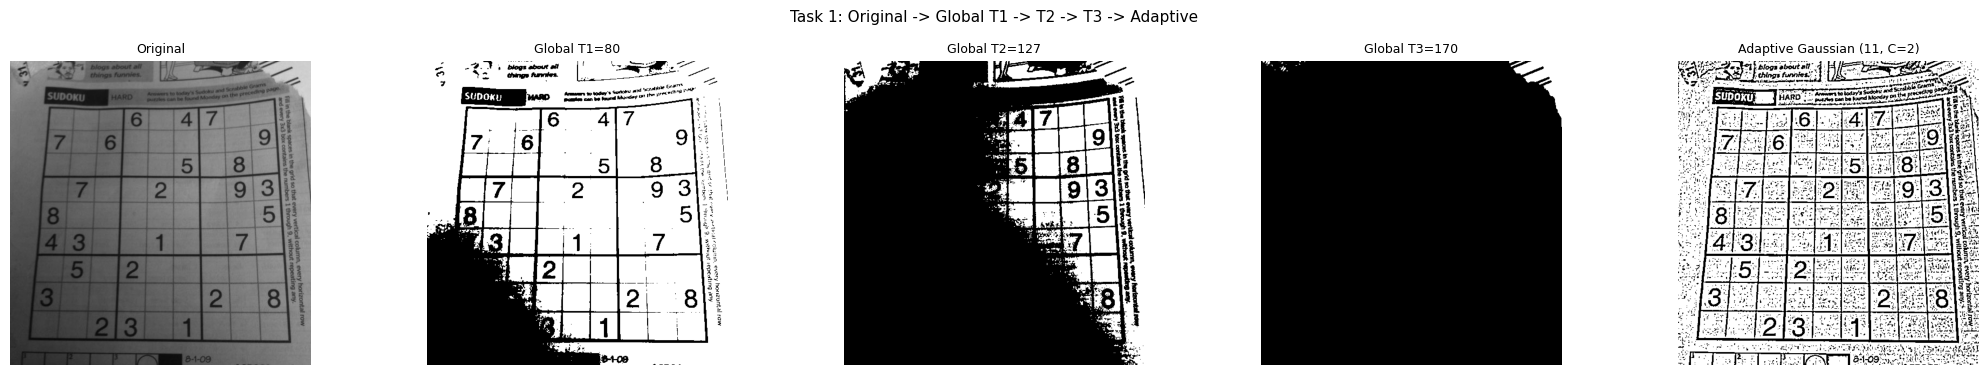

Mean brightness  left=81 right=125 top=114 bottom=86


In [ ]:
log("\n=== TASK 1: global vs adaptive thresholding (sudoku.png) ===")
gray = cv2.imread(f"{IMG}/sudoku.png", cv2.IMREAD_GRAYSCALE)
T = [80, 127, 170]
glob = [cv2.threshold(gray, t, 255, cv2.THRESH_BINARY)[1] for t in T]
adapt = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)
for t, g in zip(T, glob): log(f"global T={t}: white-pixel ratio = {g.mean()/255:.3f}")
log(f"adaptive Gaussian (block=11, C=2): white ratio = {adapt.mean()/255:.3f}")
grid([("Original", gray)] + [(f"Global T{i+1}={t}", g) for i, (t, g) in enumerate(zip(T, glob))]
     + [("Adaptive Gaussian (11, C=2)", adapt)], "task1_comparison.png",
     title="Task 1: Original -> Global T1 -> T2 -> T3 -> Adaptive")
cv2.imwrite(f"{OUT}/task1_final_adaptive.png", adapt)
h, w = gray.shape
log("Mean brightness  left=%.0f right=%.0f top=%.0f bottom=%.0f" % (
    gray[:, :w//3].mean(), gray[:, -w//3:].mean(), gray[:h//3].mean(), gray[-h//3:].mean()))

## Task 2 – Adaptive threshold parameter study


=== TASK 2: adaptive parameter study ===
MEAN     block=  5 C= 2  white ratio=0.778
MEAN     block= 11 C= 2  white ratio=0.744
MEAN     block= 11 C=10  white ratio=0.857
MEAN     block= 31 C= 2  white ratio=0.751
MEAN     block= 31 C=10  white ratio=0.826
MEAN     block= 75 C= 5  white ratio=0.783
GAUSSIAN block=  5 C= 2  white ratio=0.818
GAUSSIAN block= 11 C= 2  white ratio=0.776
GAUSSIAN block= 11 C=10  white ratio=0.890
GAUSSIAN block= 31 C= 2  white ratio=0.761
GAUSSIAN block= 31 C=10  white ratio=0.847
GAUSSIAN block= 75 C= 5  white ratio=0.799


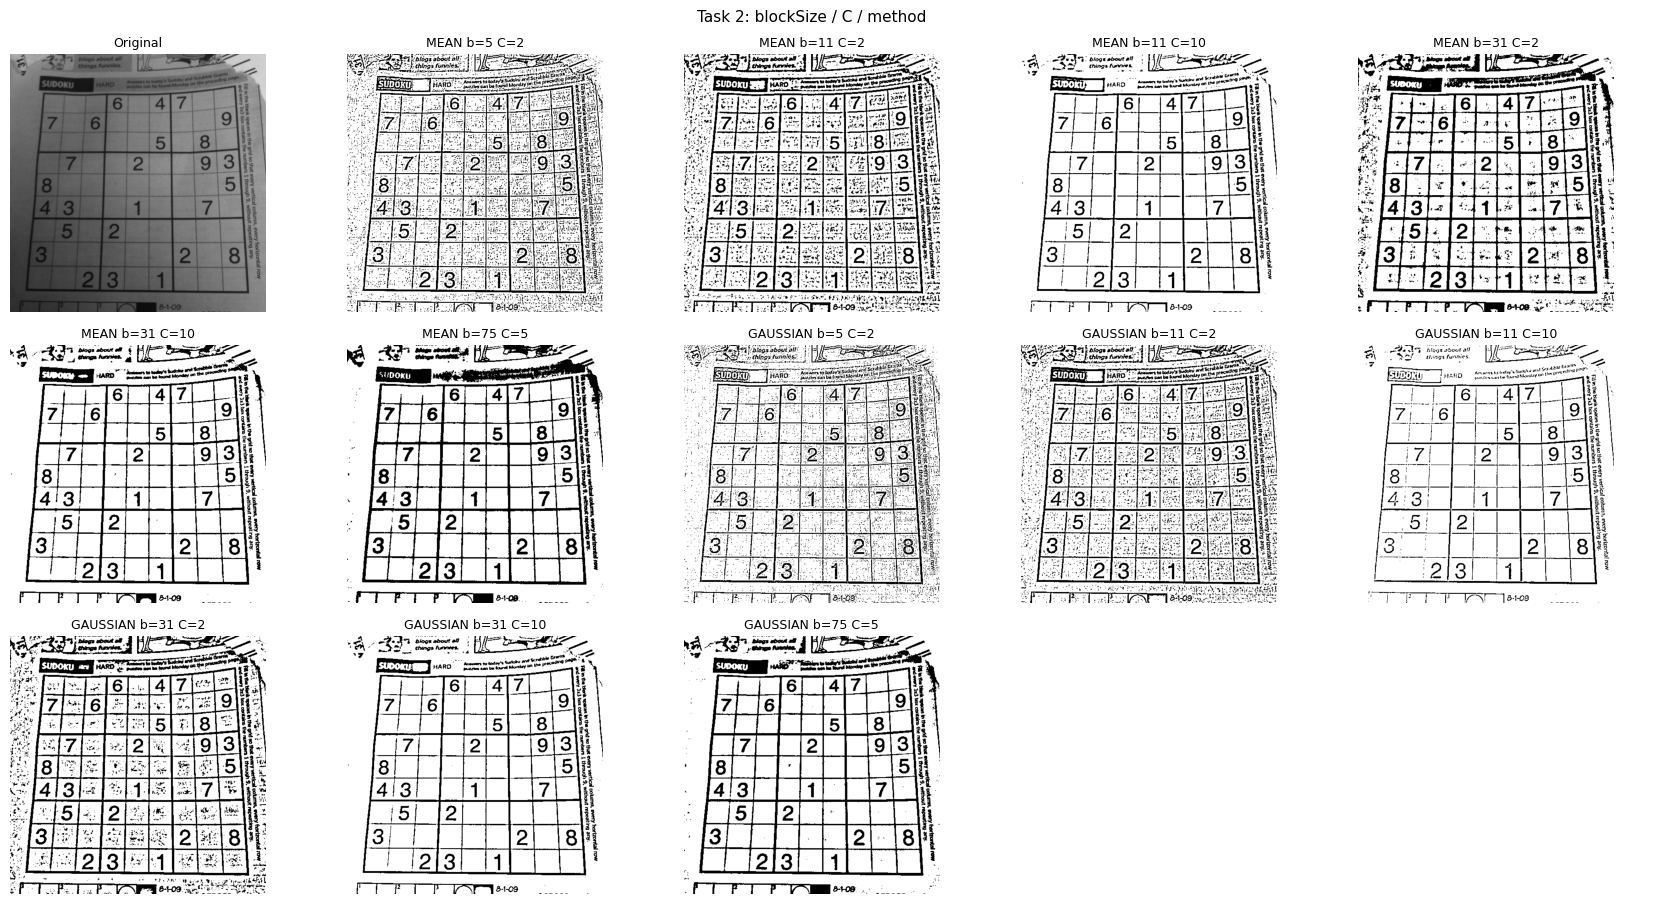

True

In [ ]:
log("\n=== TASK 2: adaptive parameter study ===")
items = [("Original", gray)]
for name, m in [("MEAN", cv2.ADAPTIVE_THRESH_MEAN_C), ("GAUSSIAN", cv2.ADAPTIVE_THRESH_GAUSSIAN_C)]:
    for bs, C in [(5, 2), (11, 2), (11, 10), (31, 2), (31, 10), (75, 5)]:
        r = cv2.adaptiveThreshold(gray, 255, m, cv2.THRESH_BINARY, bs, C)
        log(f"{name:8s} block={bs:3d} C={C:2d}  white ratio={r.mean()/255:.3f}")
        items.append((f"{name} b={bs} C={C}", r))
grid(items, "task2_parameter_comparison.png", cols=5, figw=3.4, title="Task 2: blockSize / C / method")
best = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 31, 10)
cv2.imwrite(f"{OUT}/task2_final_best.png", best)

## Task 3 – Otsu's thresholding


=== TASK 3: Otsu on coins ===
Otsu threshold [original] = 162
Otsu threshold [Gaussian blur 5x5] = 162
Otsu threshold [contrast x1.5 (alpha)] = 194
Otsu threshold [CLAHE] = 159


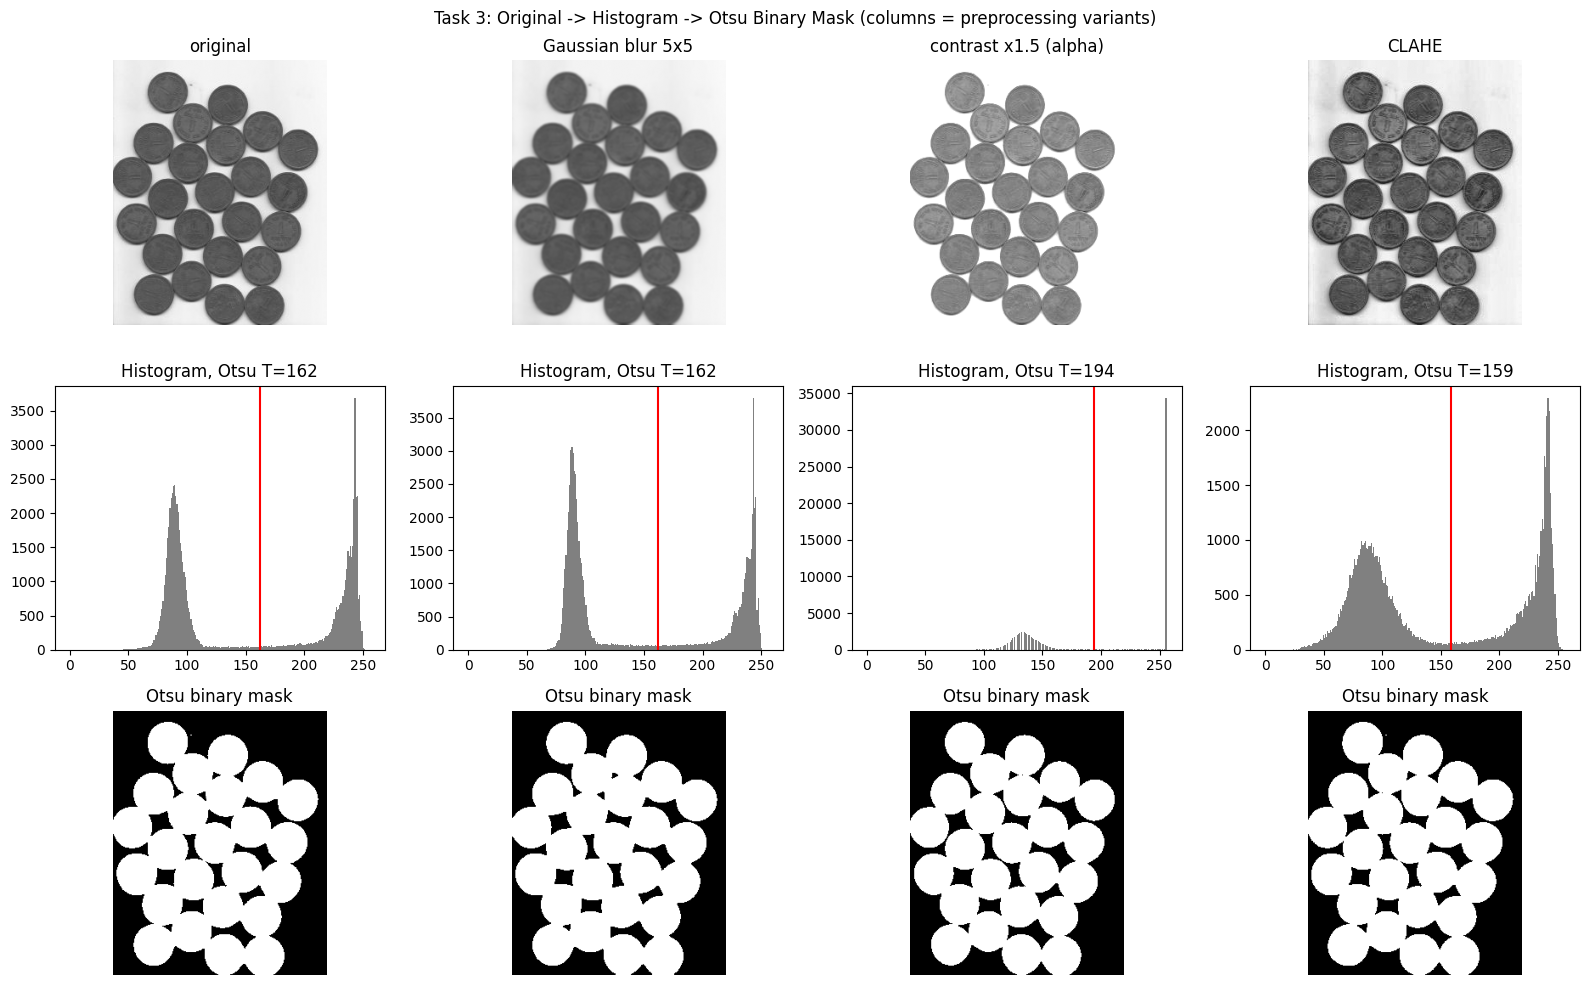

In [ ]:
log("\n=== TASK 3: Otsu on coins ===")
coins = cv2.imread(f"{IMG}/water_coins.jpg"); cg = cv2.cvtColor(coins, cv2.COLOR_BGR2GRAY)
variants = {"original": cg,
            "Gaussian blur 5x5": cv2.GaussianBlur(cg, (5, 5), 0),
            "contrast x1.5 (alpha)": cv2.convertScaleAbs(cg, alpha=1.5, beta=0),
            "CLAHE": cv2.createCLAHE(2.0, (8, 8)).apply(cg)}
fig, ax = plt.subplots(3, 4, figsize=(16, 10))
for j, (n, im) in enumerate(variants.items()):
    t, m = cv2.threshold(im, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    log(f"Otsu threshold [{n}] = {t:.0f}")
    ax[0, j].imshow(im, cmap="gray", vmin=0, vmax=255); ax[0, j].set_title(n)
    ax[1, j].hist(im.ravel(), bins=256, range=(0, 256), color="gray"); ax[1, j].axvline(t, color="r"); ax[1, j].set_title(f"Histogram, Otsu T={t:.0f}")
    ax[2, j].imshow(m, cmap="gray"); ax[2, j].set_title("Otsu binary mask")
    ax[0, j].axis("off"); ax[2, j].axis("off")
    if j == 0: cv2.imwrite(f"{OUT}/task3_final_otsu_mask.png", m)
plt.suptitle("Task 3: Original -> Histogram -> Otsu Binary Mask (columns = preprocessing variants)"); plt.tight_layout()
fig.savefig(f"{OUT}/task3_otsu.png", dpi=110); plt.show()

## Task 4 – HSV colour segmentation


=== TASK 4: HSV colour segmentation (smarties.png, green) ===
restrictive lower=[66,250,250] upper=[67,255,255] pixels: 1514
final       lower=[35,80,60]   upper=[85,255,255] pixels: 5362


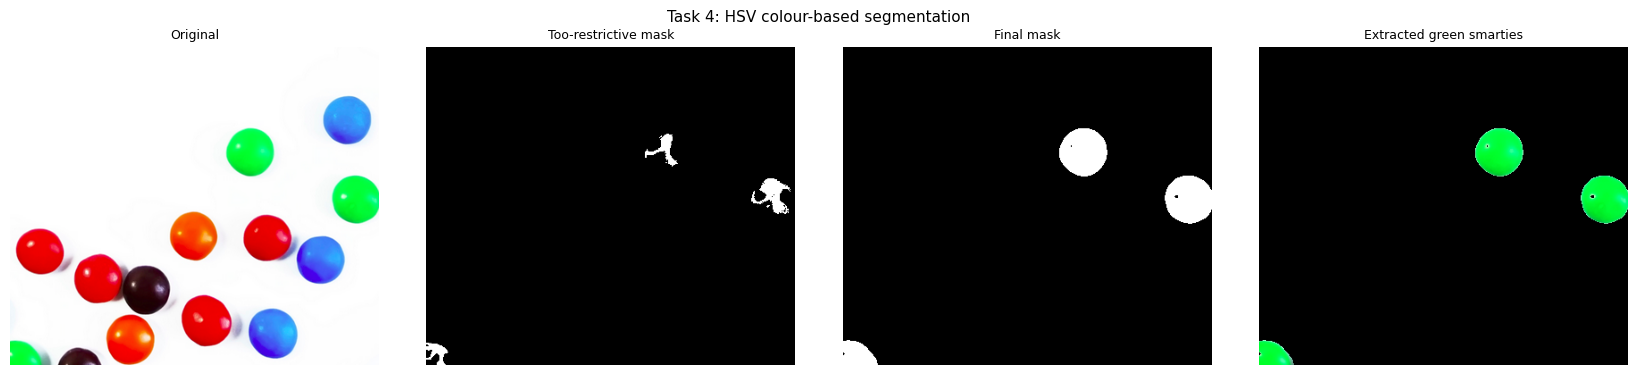

True

In [ ]:
log("\n=== TASK 4: HSV colour segmentation (smarties.png, green) ===")
sm = cv2.imread(f"{IMG}/smarties.png"); hsv = cv2.cvtColor(sm, cv2.COLOR_BGR2HSV)
restrictive = cv2.inRange(hsv, np.array([66, 250, 250]), np.array([67, 255, 255]))
final = cv2.inRange(hsv, np.array([35, 80, 60]), np.array([85, 255, 255]))
final = cv2.morphologyEx(final, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8))
log("restrictive lower=[66,250,250] upper=[67,255,255] pixels:", int((restrictive > 0).sum()))
log("final       lower=[35,80,60]   upper=[85,255,255] pixels:", int((final > 0).sum()))
extracted = cv2.bitwise_and(sm, sm, mask=final)
grid([("Original", rgb(sm)), ("Too-restrictive mask", restrictive), ("Final mask", final), ("Extracted green smarties", rgb(extracted))],
     "task4_color_segmentation.png", title="Task 4: HSV colour-based segmentation")
cv2.imwrite(f"{OUT}/task4_final_extracted.png", extracted)

## Task 5 – Canny edge detection


=== TASK 5: Canny hysteresis (smarties.png) ===
Canny low=30 high=90: edge pixels = 3391
Canny low=60 high=180: edge pixels = 3033
Canny low=100 high=250: edge pixels = 2884
Canny low=60 high=100: edge pixels = 3281


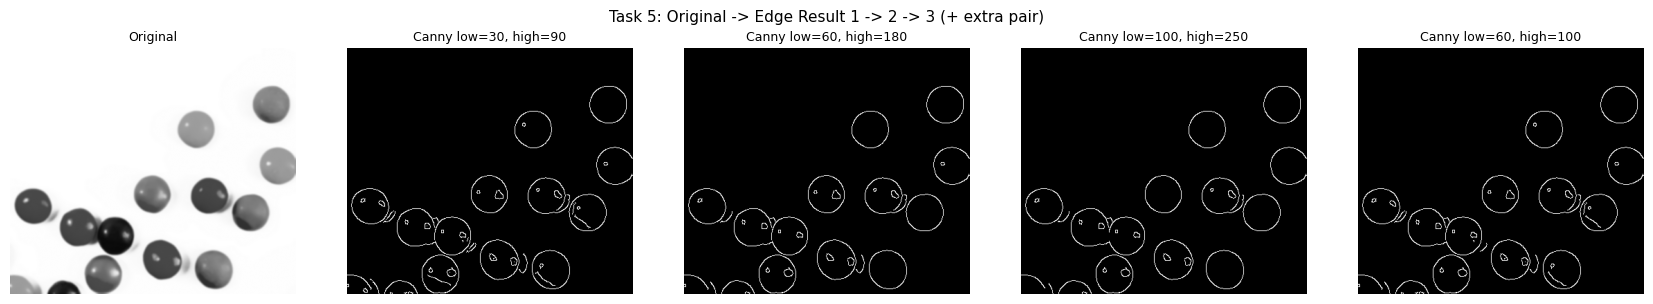

True

In [ ]:
log("\n=== TASK 5: Canny hysteresis (smarties.png) ===")
sg = cv2.GaussianBlur(cv2.cvtColor(sm, cv2.COLOR_BGR2GRAY), (5, 5), 0)
pairs = [(30, 90), (60, 180), (100, 250), (60, 100)]
edges = [cv2.Canny(sg, lo, hi) for lo, hi in pairs]
for (lo, hi), e in zip(pairs, edges): log(f"Canny low={lo} high={hi}: edge pixels = {int((e>0).sum())}")
grid([("Original", sg)] + [(f"Canny low={lo}, high={hi}", e) for (lo, hi), e in zip(pairs, edges)],
     "task5_canny.png", cols=5, figw=3.4, title="Task 5: Original -> Edge Result 1 -> 2 -> 3 (+ extra pair)")
cv2.imwrite(f"{OUT}/task5_final_canny.png", edges[1])

## Task 6 – Region growing


=== TASK 6: region growing (brain MRI) ===
seed A (cortex edge, 210,150) thr=10: region size = 58 px (seed I=138)
seed A (cortex edge, 210,150) thr=20: region size = 138 px (seed I=138)
seed A (cortex edge, 210,150) thr=35: region size = 46554 px (seed I=138)
seed B (central bright structure, 150,245) thr=10: region size = 1433 px (seed I=142)
seed B (central bright structure, 150,245) thr=20: region size = 1874 px (seed I=142)
seed B (central bright structure, 150,245) thr=35: region size = 2927 px (seed I=142)


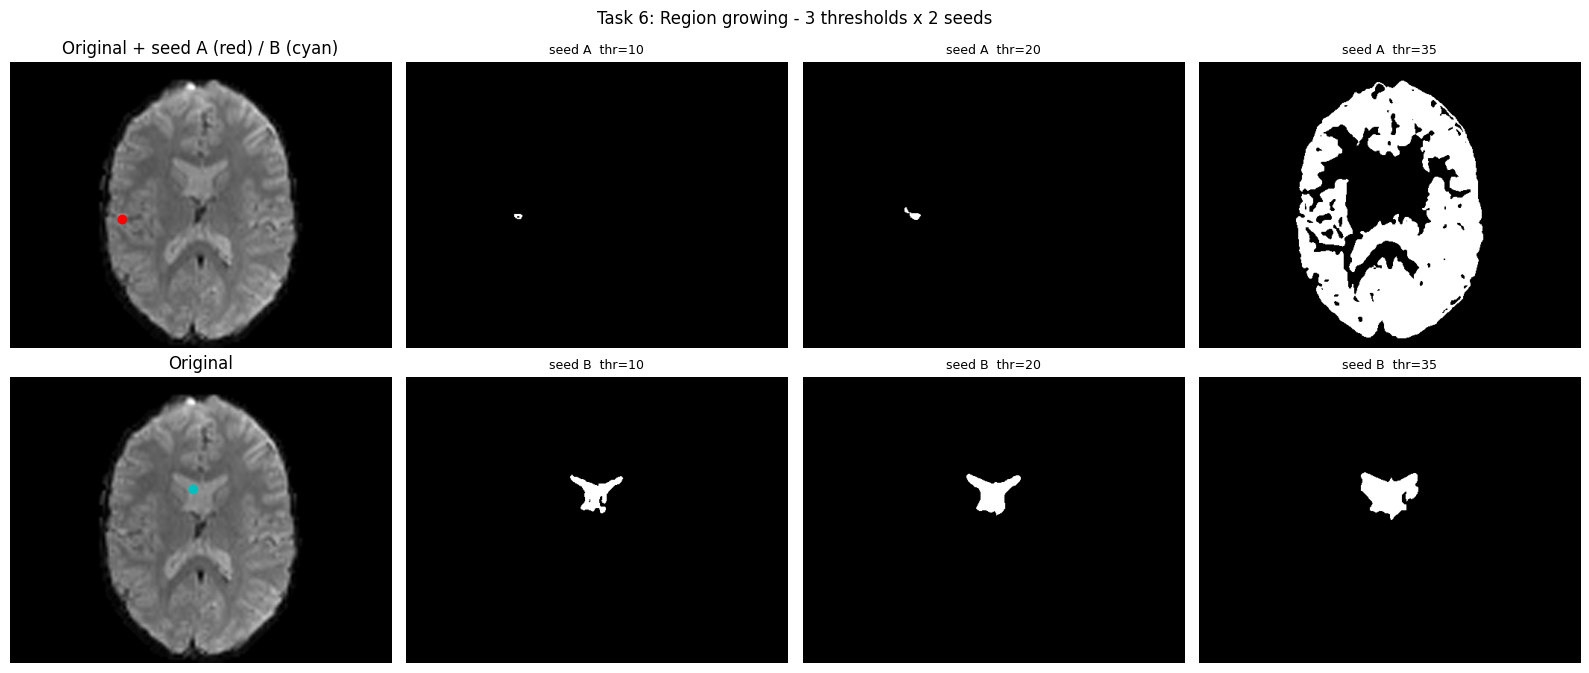

True

In [ ]:
log("\n=== TASK 6: region growing (brain MRI) ===")
brain = cv2.imread(f"{IMG}/brain_mri.png", cv2.IMREAD_GRAYSCALE)
brain_s = cv2.GaussianBlur(brain, (5, 5), 0)
def region_growing(img, seed, thr):
    """seed=(row, col); 4-connected; pixel joins if |I - I_seed| < thr."""
    H, W = img.shape; mask = np.zeros_like(img, np.uint8); r0, c0 = seed
    s = int(img[r0, c0]); q = deque([seed]); mask[r0, c0] = 255
    while q:
        r, c = q.popleft()
        for rr, cc in ((r+1, c), (r-1, c), (r, c+1), (r, c-1)):
            if 0 <= rr < H and 0 <= cc < W and mask[rr, cc] == 0 and abs(int(img[rr, cc]) - s) < thr:
                mask[rr, cc] = 255; q.append((rr, cc))
    return mask
seeds = {"seed A (cortex edge, 210,150)": (210, 150), "seed B (central bright structure, 150,245)": (150, 245)}
items = [("Original (seeds marked)", None)]; res = []
for sn, sd in seeds.items():
    for thr in (10, 20, 35):
        m = region_growing(brain_s, sd, thr); log(f"{sn} thr={thr}: region size = {int((m>0).sum())} px (seed I={brain_s[sd]})")
        res.append((f"{sn.split(' (')[0]}  thr={thr}", m))
fig, ax = plt.subplots(2, 4, figsize=(16, 7))
ax[0, 0].imshow(brain, cmap="gray"); ax[1, 0].imshow(brain, cmap="gray")
for a, (sn, sd), col in zip((ax[0, 0], ax[1, 0]), seeds.items(), ("r", "c")):
    a.plot(sd[1], sd[0], col + "o"); 
ax[0, 0].set_title("Original + seed A (red) / B (cyan)"); ax[1, 0].set_title("Original")
for i, (t, m) in enumerate(res):
    a = ax[i // 3, 1 + i % 3]; a.imshow(m, cmap="gray"); a.set_title(t, fontsize=9)
for a in ax.ravel(): a.axis("off")
plt.suptitle("Task 6: Region growing - 3 thresholds x 2 seeds"); plt.tight_layout()
fig.savefig(f"{OUT}/task6_region_growing.png", dpi=120); plt.show()
cv2.imwrite(f"{OUT}/task6_final_mask.png", region_growing(brain_s, (210, 150), 20))

## Tasks 7 & 8 – Marker-based watershed on touching coins


=== TASK 7: marker-based watershed (coins) ===
dist threshold = 0.5*max; foreground markers = 24; separated regions = 24


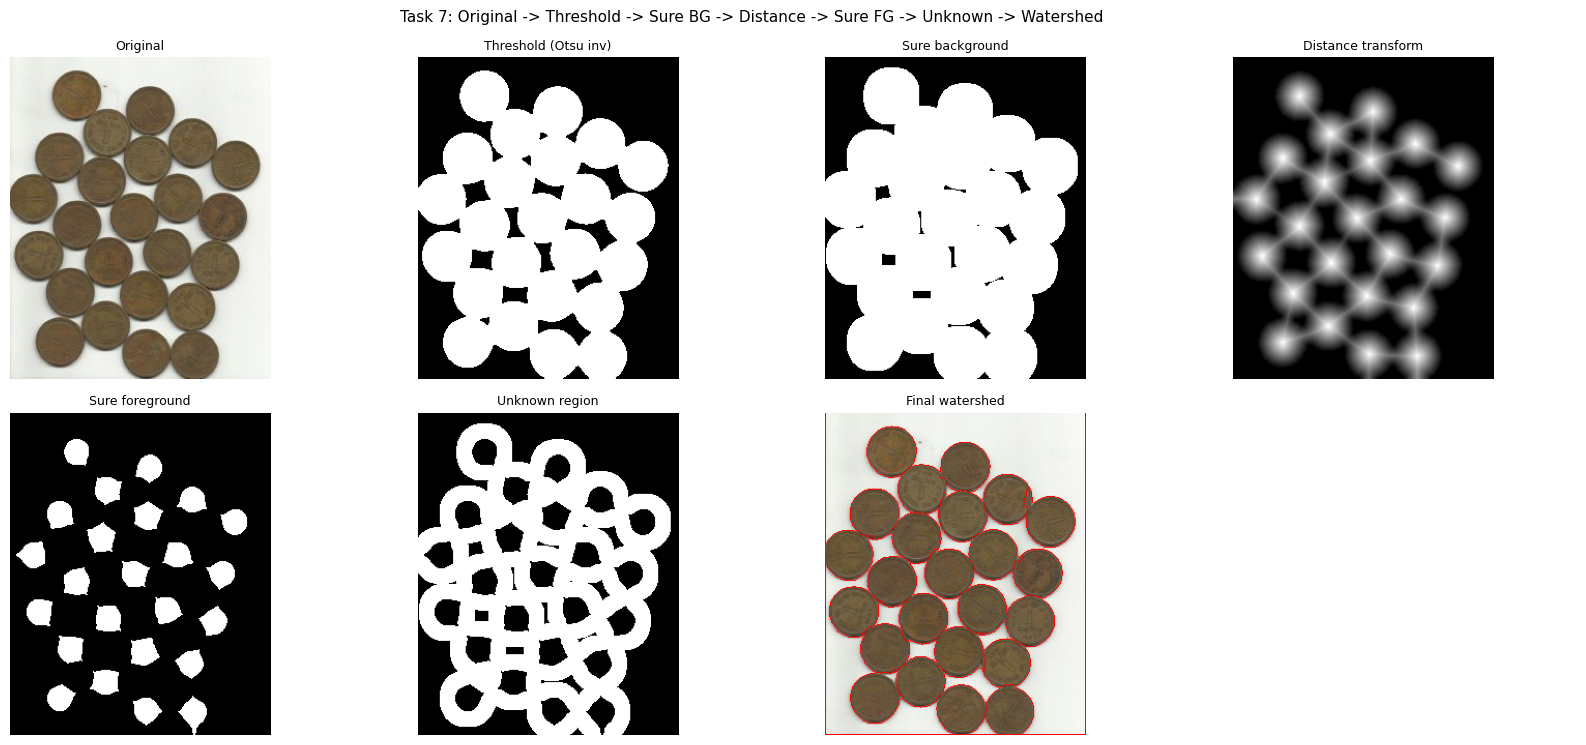


=== TASK 8: distance-transform threshold study ===
Exp | dist-thr (x max) | foreground markers | separated regions
1 | 0.2 | 1 | 1
2 | 0.4 | 7 | 7
3 | 0.6 | 24 | 24
4 | 0.8 | 24 | 24
5 | 0.95 | 24 | 24


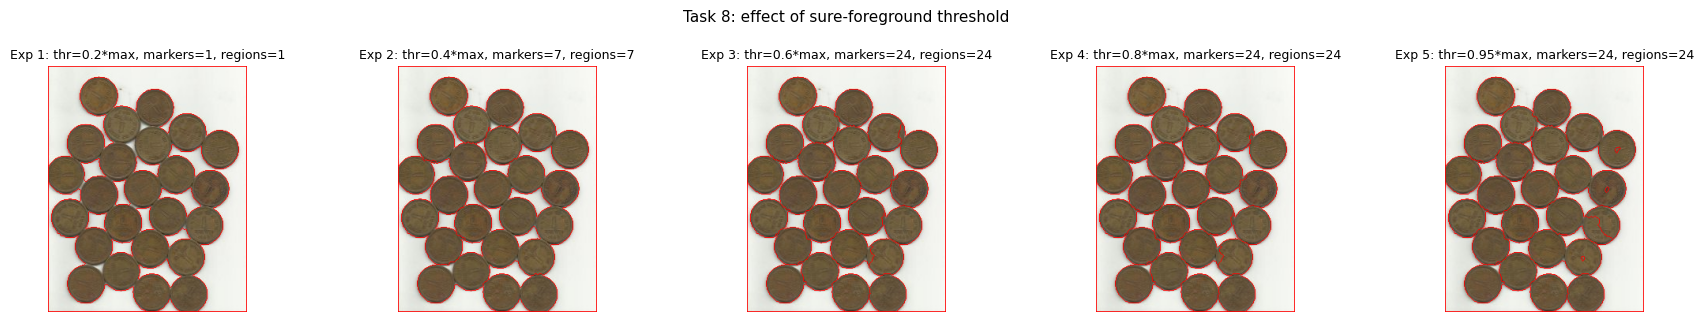

In [ ]:
def watershed_pipeline(bgr, frac=0.5, ksize=3):
    g = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    g = cv2.GaussianBlur(g, (5, 5), 0)                                             
    _, th = cv2.threshold(g, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)     
    k = np.ones((ksize, ksize), np.uint8)
    opening = cv2.morphologyEx(th, cv2.MORPH_OPEN, k, iterations=2)               
    sure_bg = cv2.dilate(opening, k, iterations=3)                              
    dist = cv2.distanceTransform(opening, cv2.DIST_L2, 5)                    
    _, sure_fg = cv2.threshold(dist, frac * dist.max(), 255, 0)                
    sure_fg = np.uint8(sure_fg)
    unknown = cv2.subtract(sure_bg, sure_fg)                           
    n, markers = cv2.connectedComponents(sure_fg)                         
    markers = markers + 1; markers[unknown == 255] = 0
    out = bgr.copy(); markers = cv2.watershed(out, markers)          
    out[markers == -1] = [0, 0, 255]                                       
    return dict(th=th, sure_bg=sure_bg, dist=dist, sure_fg=sure_fg, unknown=unknown, markers=markers, out=out, n_fg=n - 1)

log("\n=== TASK 7: marker-based watershed (coins) ===")
r = watershed_pipeline(coins, 0.5)
n_regions = len(np.unique(r["markers"])) - 2      
log(f"dist threshold = 0.5*max; foreground markers = {r['n_fg']}; separated regions = {n_regions}")
dn = cv2.normalize(r["dist"], None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
grid([("Original", rgb(coins)), ("Threshold (Otsu inv)", r["th"]), ("Sure background", r["sure_bg"]),
      ("Distance transform", dn), ("Sure foreground", r["sure_fg"]), ("Unknown region", r["unknown"]),
      ("Final watershed", rgb(r["out"]))], "task7_watershed_pipeline.png", cols=4, figw=4.2,
     title="Task 7: Original -> Threshold -> Sure BG -> Distance -> Sure FG -> Unknown -> Watershed")
cv2.imwrite(f"{OUT}/task7_final_watershed.png", r["out"])

log("\n=== TASK 8: distance-transform threshold study ===")
log("Exp | dist-thr (x max) | foreground markers | separated regions")
items = []
for i, f in enumerate([0.2, 0.4, 0.6, 0.8, 0.95], 1):
    rr = watershed_pipeline(coins, f); nreg = len(np.unique(rr["markers"])) - 2
    log(f"{i} | {f} | {rr['n_fg']} | {nreg}")
    items.append((f"Exp {i}: thr={f}*max, markers={rr['n_fg']}, regions={nreg}", rgb(rr["out"])))
grid(items, "task8_watershed_tuning.png", cols=5, figw=3.6, title="Task 8: effect of sure-foreground threshold")

## Task 9 – K-Means colour segmentation


=== TASK 9: K-Means colour segmentation (dog.jpeg) ===
K=2: clusters=2, MSE vs original=920.7, centres(BGR)=[[37, 62, 46], [211, 208, 209]], share%=[67.7, 32.3]
K=4: clusters=4, MSE vs original=317.8, centres(BGR)=[[17, 31, 21], [229, 226, 227], [156, 155, 155], [47, 82, 60]], share%=[27.7, 23.4, 10.9, 38.0]
K=6: clusters=6, MSE vs original=167.4, centres(BGR)=[[63, 95, 74], [238, 236, 237], [13, 22, 16], [199, 193, 195], [34, 68, 45], [140, 142, 140]], share%=[15.8, 16.4, 20.0, 10.9, 29.8, 7.0]


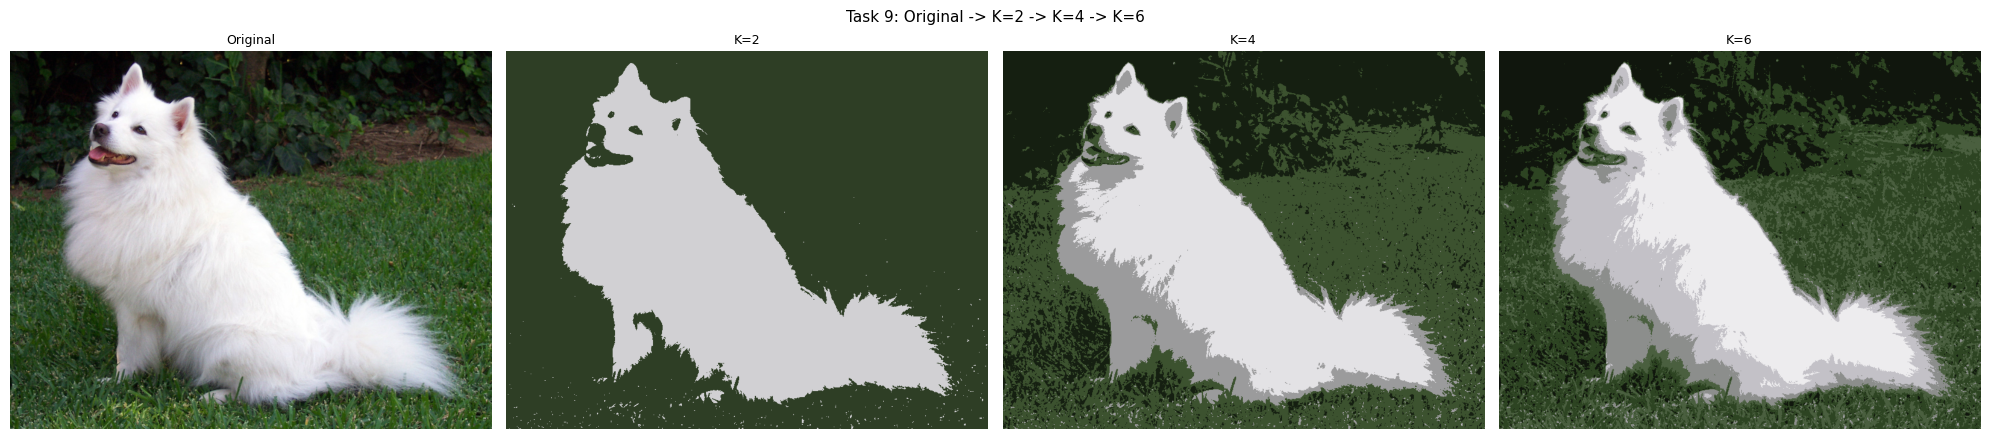

True

In [ ]:
log("\n=== TASK 9: K-Means colour segmentation (dog.jpeg) ===")
dog = cv2.imread(f"{IMG}/dog.jpeg"); s = 800 / dog.shape[1]; dog = cv2.resize(dog, None, fx=s, fy=s, interpolation=cv2.INTER_AREA)
pix = np.float32(dog.reshape(-1, 3))
crit = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
items = [("Original", rgb(dog))]; km = {}
for K in (2, 4, 6):
    _, lab, cen = cv2.kmeans(pix, K, None, crit, 5, cv2.KMEANS_PP_CENTERS)
    seg = np.uint8(cen)[lab.flatten()].reshape(dog.shape); km[K] = seg
    mse = np.mean((seg.astype(float) - dog) ** 2)
    log(f"K={K}: clusters={K}, MSE vs original={mse:.1f}, centres(BGR)={np.uint8(cen).tolist()}, share%={np.round(100*np.bincount(lab.flatten())/lab.size,1).tolist()}")
    items.append((f"K={K}", rgb(seg)))
grid(items, "task9_kmeans.png", cols=4, figw=5, title="Task 9: Original -> K=2 -> K=4 -> K=6")
cv2.imwrite(f"{OUT}/task9_final_K4.png", km[4])

## Task 10 – Segmentation system for an unknown image


=== TASK 10: three approaches on dog.jpeg (Otsu / Canny / K-Means) ===
Otsu threshold = 132, white ratio = 0.318
Canny(50,150) edge pixels = 22651
  Canny(20,60) edge pixels = 77098
  Canny(100,200) edge pixels = 7145
  K-Means K=3: MSE=569.6
  K-Means K=4: MSE=318.0
  K-Means K=5: MSE=226.7


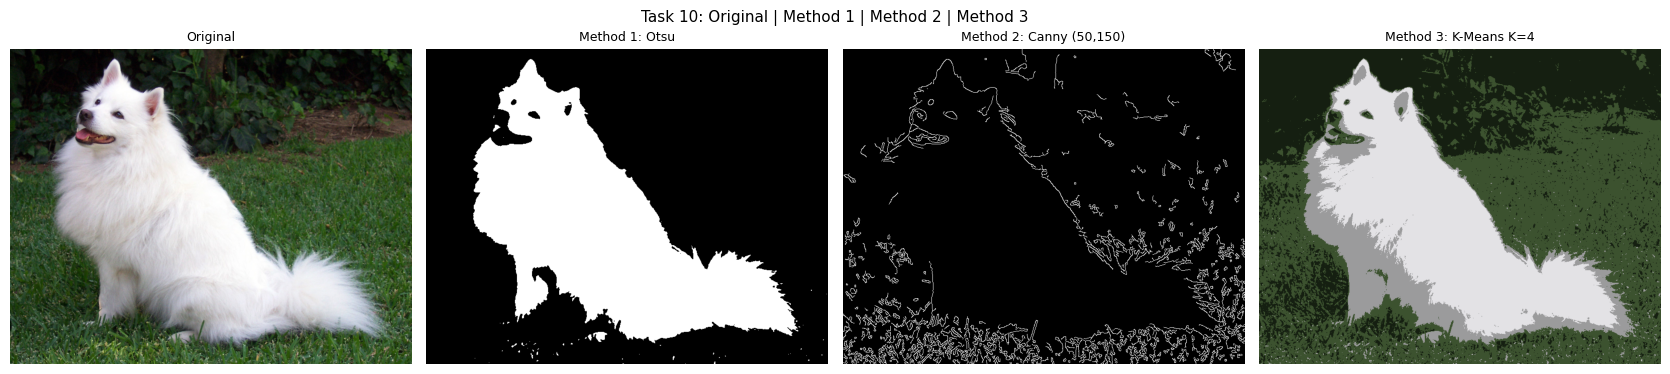

done - outputs saved in ./results


In [ ]:
log("\n=== TASK 10: three approaches on dog.jpeg (Otsu / Canny / K-Means) ===")
dg = cv2.GaussianBlur(cv2.cvtColor(dog, cv2.COLOR_BGR2GRAY), (5, 5), 0)
t, otsu = cv2.threshold(dg, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
log(f"Otsu threshold = {t:.0f}, white ratio = {otsu.mean()/255:.3f}")
can = cv2.Canny(dg, 50, 150); log(f"Canny(50,150) edge pixels = {int((can>0).sum())}")
for lo, hi in [(20, 60), (100, 200)]: log(f"  Canny({lo},{hi}) edge pixels = {int((cv2.Canny(dg,lo,hi)>0).sum())}")
for K in (3, 4, 5):
    _, lab, cen = cv2.kmeans(pix, K, None, crit, 5, cv2.KMEANS_PP_CENTERS)
    log(f"  K-Means K={K}: MSE={np.mean((np.uint8(cen)[lab.flatten()].reshape(dog.shape).astype(float)-dog)**2):.1f}")
grid([("Original", rgb(dog)), ("Method 1: Otsu", otsu), ("Method 2: Canny (50,150)", can), ("Method 3: K-Means K=4", rgb(km[4]))],
     "task10_final_comparison.png", title="Task 10: Original | Method 1 | Method 2 | Method 3")
LOG.close(); print("done - outputs saved in ./results")